# 🔧 Feature Engineering

Bu notebook'ta fraud detection modeli için gelişmiş özellikler (features) oluşturulacaktır.

## 📋 İçerik
1. **Veri Yükleme** - Optimize edilmiş veri setinin yüklenmesi
2. **Temporal Features** - Zaman bazlı özellikler
3. **User Identification (UID)** - Chris Deotte yaklaşımı ile kullanıcı tanımlama
4. **UID Behavioral Features** - Kullanıcı davranış özellikleri
5. **Card1 Features** - Kart bazlı istatistikler
6. **Psychological Amount Features** - Psikolojik tutar analizi
7. **Feature Selection** - Özellik seçimi ve korelasyon analizi
8. **Model Training** - LightGBM ile model eğitimi
9. **Feature Importance** - Özellik önem analizi

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, 
                             precision_score, recall_score, f1_score, roc_curve)
from lightgbm import LGBMClassifier

# Configuration
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Veri Yükleme

In [2]:
# Load optimized dataset
with open('../../data/train_test_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

# Display dataset summary
print("DATASET SUMMARY")
print(f"\nTotal records     : {len(df):,}")
print(f"Train records     : {(df['_source'] == 'train').sum():,}")
print(f"Test records      : {(df['_source'] == 'test').sum():,}")
print(f"\nMemory usage      : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Fraud rate (train): {df[df['_source']=='train']['isFraud'].mean()*100:.2f}%")


DATASET SUMMARY

Total records     : 1,097,231
Train records     : 590,540
Test records      : 506,691

Memory usage      : 1569.98 MB
Fraud rate (train): 3.50%


## 2. Temporal Features (Zaman Bazlı Özellikler)

Zaman bazlı agregasyonlar için hafta ve ay numarası oluşturulacaktır. Bu özellikler geçici olup, feature engineering tamamlandıktan sonra silinecektir.

In [3]:
# Create temporal features for aggregations
df['week_num'] = (df['TransactionDT'] // 604800).astype('int16')   # 1 week = 604800 seconds
df['month_num'] = (df['week_num'] // 4).astype('int16')            # ~4 weeks = 1 month

print("TEMPORAL FEATURES")
print("-" * 40)
print(f"Week range  : {df['week_num'].min()} - {df['week_num'].max()} ({df['week_num'].nunique()} weeks)")
print(f"Month range : {df['month_num'].min()} - {df['month_num'].max()} ({df['month_num'].nunique()} months)")

TEMPORAL FEATURES
----------------------------------------
Week range  : 0 - 56 (54 weeks)
Month range : 0 - 14 (15 months)


## 3. User Identification (UID)

Kullanıcı tanımlama için **D1n** (kullanıcının ilk işlem günü) hesaplanır. Bu değer sabit bir anchor olarak kullanılır ve aynı kullanıcının her zaman aynı UID'ye sahip olmasını sağlar.

**Formül:** `D1n = floor(TransactionDT / 86400) - D1`

In [4]:
# D1n: User's first transaction day (fixed anchor point)
df['D1n'] = np.floor(df['TransactionDT'] / 86400) - df['D1']

# UID: Combination of card1 + addr1 + D1n
df['uid'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['D1n'].astype(str)

# User Anchor D1 (alternative feature)
df['user_anchor_D1'] = df['TransactionDT'] - (df['D1'] * 86400)

print("USER IDENTIFICATION")
print(f"\nD1n unique values    : {df['D1n'].nunique():,}")
print(f"D1n missing          : {df['D1n'].isna().sum():,} ({df['D1n'].isna().mean()*100:.1f}%)")
print(f"UID unique users     : {df['uid'].nunique():,}")
print(f"User Anchor unique   : {df['user_anchor_D1'].nunique():,}")

USER IDENTIFICATION

D1n unique values    : 1,004
D1n missing          : 7,300 (0.7%)
UID unique users     : 353,479
User Anchor unique   : 1,071,580


**Çıkarımlar:**
- UID kombinasyonu (card1 + addr1 + D1n) ile benzersiz kullanıcılar tanımlanmıştır
- D1n değeri kullanıcının "başlangıç gününü" temsil eder
- Bu yaklaşım aynı kullanıcının farklı işlemlerini tutarlı bir şekilde gruplar

---
## 4. UID Behavioral Features (Kullanıcı Davranış Özellikleri)

Kullanıcı bazlı istatistikler hesaplanacaktır:
- **Genel istatistikler:** Ortalama, standart sapma, max, min, toplam tutar
- **Haftalık istatistikler:** Haftalık ortalama tutar ve işlem sayısı
- **Aylık istatistikler:** Aylık ortalama tutar ve işlem sayısı
- **Anomali oranları:** Mevcut işlem tutarının ortalamaya oranı

**⚠️ Yüksek Korelasyon Uyarısı:**

Aşağıdaki özellikler yüksek korelasyon (|r| > 0.8) nedeniyle feature selection aşamasında çıkarılacaktır:
- `uid_txn_count` (corr=0.989 with uid_total_amt)
- `uid_month_txn_count` (corr=0.945 with uid_total_amt)
- `uid_week_avg_amt` (corr=0.833 with uid_month_avg_amt)
- `amt_vs_uid_week_avg` (corr=0.894 with amt_vs_uid_month_avg)
- `amt_vs_uid_avg` (corr=0.873 with amt_vs_uid_month_avg)

---
## 5. Card1 Features (Kart Bazlı Özellikler)

Her kart için istatistikler hesaplanır. **Önemli:** Data leakage önlemek için sadece train verisi kullanılır.

In [5]:
# Card1 aggregation features (Train-only to prevent data leakage)
train_data = df[df['_source'] == 'train'].copy()

card1_agg = train_data.groupby('card1').agg({
    'TransactionAmt': 'max',
    'addr1': 'nunique',
    'DeviceInfo': 'nunique'
}).reset_index()
card1_agg.columns = ['card1', 'card1_amt_max', 'card1_n_addr', 'card1_n_devices']

# Merge to all data
df = df.merge(card1_agg, on='card1', how='left')

# Fill missing values with sensible defaults
df['card1_amt_max'] = df['card1_amt_max'].fillna(df['TransactionAmt'])
df['card1_n_addr'] = df['card1_n_addr'].fillna(1)
df['card1_n_devices'] = df['card1_n_devices'].fillna(1)

print("CARD1 FEATURES CREATED (Train-Only)")
print("-" * 40)
print("card1_amt_max    : Maximum transaction amount per card")
print("card1_n_addr     : Unique addresses per card")
print("card1_n_devices  : Unique devices per card")
print(f"\n No data leakage - computed from TRAIN only")

CARD1 FEATURES CREATED (Train-Only)
----------------------------------------
card1_amt_max    : Maximum transaction amount per card
card1_n_addr     : Unique addresses per card
card1_n_devices  : Unique devices per card

 No data leakage - computed from TRAIN only


---
## 6. Psychological Amount Features (Psikolojik Tutar Özellikleri)

İnsanlar belirli sayıları tercih eder: yuvarlak sayılar (100, 500) veya psikolojik fiyatlar (99, 199). Fraud botları genellikle rastgele sayılar üretir. Bu davranış farklılığı fraud detection için önemli bir sinyal olabilir.

**Tutar Kategorileri:**
- **Round (Yuvarlak):** 10.00, 50.00, 100.00, 500.00
- **Psychological (Psikolojik):** 9.99, 49.99, 99.95, 199.99
- **Random (Rastgele):** Diğer tüm değerler

In [6]:
def classify_amount_type(amount):
    """
    Classify transaction amount into categories:
    - 'round': Round numbers (10.00, 50.00, 100.00, 500.00)
    - 'psychological': Psychological pricing (9.99, 49.99, 99.95)
    - 'random': Other numbers (real transactions: 123.47, 87.32)
    """
    int_part = int(amount)
    cents = round((amount - int_part) * 100)
    
    # Round numbers (whole dollars)
    if cents == 0 and (int_part % 100 == 0 or int_part % 50 == 0 or int_part % 10 == 0):
        return 'round'
    
    # Psychological pricing (.99, .95, .90)
    if cents in [99, 95] or (cents == 90 and int_part % 10 == 9):
        return 'psychological'
    
    # Psychological whole numbers ending in 9 or 5
    if cents == 0 and int_part % 10 in [9, 5]:
        return 'psychological'
    
    return 'random'

# Create amount type feature
df['amt_type'] = df['TransactionAmt'].apply(classify_amount_type)

# Binary features for each type
df['is_round_amount'] = (df['amt_type'] == 'round').astype('int8')
df['is_psych_amount'] = (df['amt_type'] == 'psychological').astype('int8')
df['is_random_amount'] = (df['amt_type'] == 'random').astype('int8')

# Cents analysis
df['amt_cents'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 100).round().astype('int16')
df['has_cents'] = (df['amt_cents'] > 0).astype('int8')
df['is_99_cents'] = (df['amt_cents'] == 99).astype('int8')
df['is_95_cents'] = (df['amt_cents'] == 95).astype('int8')
df['is_round_cents'] = (df['amt_cents'] % 10 == 0).astype('int8')

# Display distribution
print("PSYCHOLOGICAL AMOUNT FEATURES")
print("-" * 40)
amt_dist = df['amt_type'].value_counts()
for amt_type, count in amt_dist.items():
    pct = count / len(df) * 100
    print(f"{amt_type:<15}: {count:>10,} ({pct:>5.1f}%)")

# Fraud rate by amount type (train only)
train_mask = df['_source'] == 'train'
print(f"\nFraud Rate by Amount Type (Train):")
for amt_type in ['round', 'psychological', 'random']:
    mask = train_mask & (df['amt_type'] == amt_type)
    if mask.sum() > 0:
        fraud_rate = df[mask]['isFraud'].mean() * 100
        print(f"{amt_type:<15}: {fraud_rate:>5.2f}%")

PSYCHOLOGICAL AMOUNT FEATURES
----------------------------------------
psychological  :    522,060 ( 47.6%)
random         :    422,554 ( 38.5%)
round          :    152,617 ( 13.9%)

Fraud Rate by Amount Type (Train):
round          :  4.45%
psychological  :  1.58%
random         :  5.53%


**Çıkarımlar:**
- Random (rastgele) tutarlar en yüksek fraud oranına sahip olabilir
- Psikolojik fiyatlandırma genellikle meşru alışverişleri temsil eder
- Bu özellikler bot vs. insan davranışını ayırt etmeye yardımcı olabilir

---
## 7. Missing Value Handling (Eksik Değer Yönetimi)

In [7]:
# Missing value filling strategy:
# - Aggregation features (avg, std, count) → 0 (no history)
# - Ratio features (amt vs avg) → 1.0 (neutral ratio)

agg_feature_patterns = ['_avg_amt', '_std_amt', '_max_amt', '_min_amt', 
                         '_total_amt', '_txn_count', '_week_avg', '_month_avg']
ratio_feature_patterns = ['amt_vs_']

# Fill aggregation features with 0
for col in df.columns:
    if any(pattern in col for pattern in agg_feature_patterns):
        df[col] = df[col].fillna(0)

# Fill ratio features with 1.0
for col in df.columns:
    if any(pattern in col for pattern in ratio_feature_patterns):
        df[col] = df[col].fillna(1.0)

print("MISSING VALUE HANDLING")
print("\nAggregation features → 0 (no history)")
print("Ratio features       → 1.0 (neutral)")
print("✅ Missing values handled")

MISSING VALUE HANDLING

Aggregation features → 0 (no history)
Ratio features       → 1.0 (neutral)
✅ Missing values handled


---
## 8. Cleanup & Feature Selection

In [8]:
# Remove temporary columns used for aggregation
temp_cols = ['week_num', 'month_num']
df = df.drop(columns=temp_cols, errors='ignore')

print("CLEANUP")
print("-" * 40)
print(f"Removed: {temp_cols}")
print(f"Final dataset shape: {df.shape}")

CLEANUP
----------------------------------------
Removed: ['week_num', 'month_num']
Final dataset shape: (1097231, 488)


In [9]:
# Fraud correlation analysis for new features
train_data = df[df['_source'] == 'train'].copy()

new_features = [
    'uid_TransactionAmt_mean', 'uid_TransactionAmt_std', 'uid_D4n_mean', 'uid_D4n_std',
    'uid_D10n_mean', 'uid_D10n_std', 'uid_D15n_mean', 'uid_D15n_std', 'uid_dist1_mean',
    'uid_dist1_std', 'uid_C13_nunique', 'card1_TransactionAmt_mean', 'card1_TransactionAmt_std',
    'card1_amt_max', 'card1_n_addr', 'card1_n_devices', 'amt_vs_uid_mean', 'amt_vs_card1_mean',
    'is_round_amount', 'is_psych_amount', 'is_random_amount', 'amt_cents', 'has_cents',
    'is_99_cents', 'is_95_cents', 'is_round_cents', 'user_anchor_D1'
]

# Filter existing numeric features
numeric_features = [col for col in new_features 
                    if col in train_data.columns 
                    and train_data[col].dtype in ['float64', 'float32', 'int64', 'int32', 'int16', 'int8']]

if numeric_features:
    correlations = train_data[numeric_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
    correlations = correlations.abs().sort_values(ascending=False)
    
    print("TOP 20 FEATURES BY FRAUD CORRELATION\n")
    
    for idx, (feat, corr) in enumerate(correlations.head(20).items(), 1):
        print(f"{idx:2d}. {feat:<40}: {corr:.4f}")

TOP 20 FEATURES BY FRAUD CORRELATION

 1. is_psych_amount                         : 0.0998
 2. is_95_cents                             : 0.0946
 3. is_random_amount                        : 0.0878
 4. card1_n_devices                         : 0.0757
 5. amt_cents                               : 0.0488
 6. is_round_amount                         : 0.0206
 7. card1_amt_max                           : 0.0155
 8. card1_n_addr                            : 0.0118
 9. is_round_cents                          : 0.0062
10. is_99_cents                             : 0.0051
11. has_cents                               : 0.0045


**Çıkarımlar:**
- En yüksek fraud korelasyonuna sahip özellikler modelde önemli olacaktır
- Düşük korelasyonlu özellikler çıkarılabilir veya dönüştürülebilir

---
## 9. Train/Test Split

In [10]:
# Split into train and test sets
train_df = df[df['_source'] == 'train'].drop('_source', axis=1).copy()
test_df = df[df['_source'] == 'test'].drop('_source', axis=1).copy()

print("TRAIN/TEST SPLIT\n")
print(f"Train shape      : {train_df.shape}")
print(f"Test shape       : {test_df.shape}")
print(f"Train fraud rate : {train_df['isFraud'].mean()*100:.2f}%")

TRAIN/TEST SPLIT

Train shape      : (590540, 487)
Test shape       : (506691, 487)
Train fraud rate : 3.50%


---
## 10. Feature Selection

Model için kullanılacak özellikler seçilir. Aşağıdakiler hariç tutulur:
- V kolonları (yüksek boyutlu)
- id, D, C, M kolonları (ham özellikler)
- Geçici kolonlar (uid, D1n vb.)

In [11]:
# Feature selection: exclude raw features and temporary columns
exclude_prefixes = ['V', 'id_', 'id-', 'M', 'C']
exclude_exact = ['TransactionID', 'isFraud', 'uid', 'D1n', 'D4n', 'D10n', 'D15n', 
                 'uid_card1_addr1', 'week_num', 'month_num']

# Select features
all_cols = train_df.columns.tolist()
other_cols = [col for col in all_cols 
              if not any(col.startswith(prefix) for prefix in exclude_prefixes)
              and col not in exclude_exact
              and not (col.startswith('D') and col[1:].isdigit())]

# Drop high correlation features
high_corr_to_drop = ['card1_TransactionAmt_std', 'uid_TransactionAmt_std']
high_corr_existing = [col for col in high_corr_to_drop if col in other_cols]
other_cols = [col for col in other_cols if col not in high_corr_existing]

print("FEATURE SELECTION\n")
print(f"Total columns         : {len(all_cols)}")
print(f"Selected features     : {len(other_cols)}")

if high_corr_existing:
    print(f"\n⚠️ Dropped (high correlation): {high_corr_existing}")

print(f"\nFeatures ({len(other_cols)}):")
for i, col in enumerate(other_cols, 1):
    print(f"  {i:2d}. {col}")

FEATURE SELECTION

Total columns         : 487
Selected features     : 30

Features (30):
   1. TransactionDT
   2. TransactionAmt
   3. ProductCD
   4. card1
   5. card2
   6. card3
   7. card4
   8. card5
   9. card6
  10. addr1
  11. addr2
  12. dist1
  13. dist2
  14. P_emaildomain
  15. R_emaildomain
  16. DeviceType
  17. DeviceInfo
  18. user_anchor_D1
  19. card1_amt_max
  20. card1_n_addr
  21. card1_n_devices
  22. amt_type
  23. is_round_amount
  24. is_psych_amount
  25. is_random_amount
  26. amt_cents
  27. has_cents
  28. is_99_cents
  29. is_95_cents
  30. is_round_cents


---
## 11. Multicollinearity Analysis (Çoklu Doğrusallık Analizi)

MULTICOLLINEARITY ANALYSIS
Continuous variables: 5

✅ No high correlation pairs found


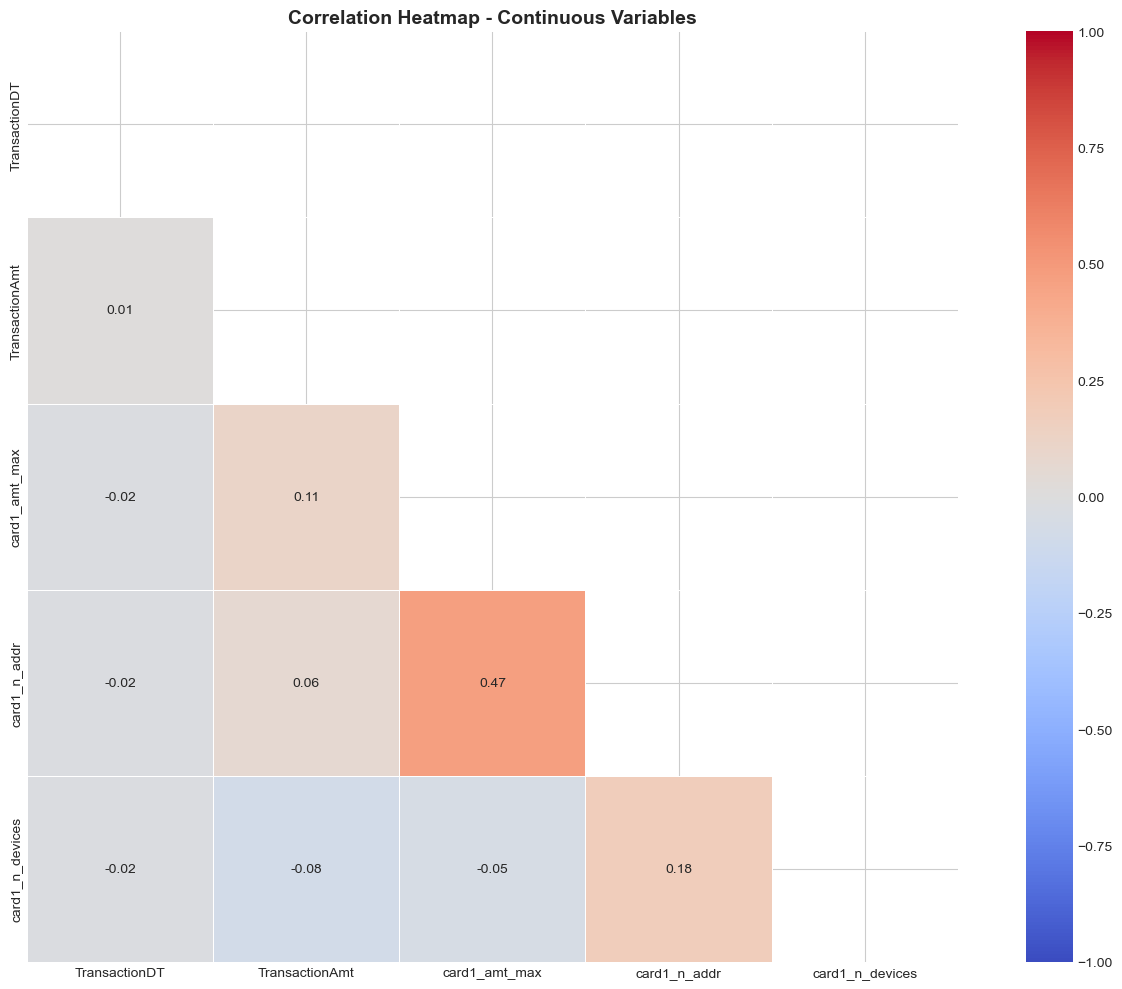

In [12]:
# Identify continuous variables for correlation analysis
continuous_cols = [col for col in other_cols 
                   if train_df[col].dtype in ['float64', 'float32', 'int64', 'int32']
                   and train_df[col].nunique() > 20]

print(f"MULTICOLLINEARITY ANALYSIS")
print(f"Continuous variables: {len(continuous_cols)}")

# Calculate correlation matrix
corr_matrix = train_df[continuous_cols].corr()

# Find highly correlated pairs (|r| > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\n⚠️ HIGH CORRELATION PAIRS (|r| > 0.8): {len(high_corr_pairs)}")
    print("-" * 80)
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True)[:10]:
        print(f"  {pair['var1']:<30} ↔ {pair['var2']:<30} : {pair['correlation']:>6.3f}")
else:
    print("\n✅ No high correlation pairs found")

# Create correlation heatmap
if len(continuous_cols) <= 20:
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Correlation Heatmap - Continuous Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Çıkarımlar:**
- Yüksek korelasyonlu (|r| > 0.8) değişken çiftleri modelde multicollinearity sorununa yol açabilir
- Bu çiftlerden birinin çıkarılması veya birleştirilmesi düşünülebilir
- LightGBM bu duruma nispeten dayanıklıdır, ancak yine de gereksiz özellikler performansı düşürebilir

In [13]:
# High correlation check for new aggregation features
new_agg_features = [col for col in other_cols 
                    if any(x in col for x in ['_mean', '_std', '_nunique', '_max', '_n_'])]

if len(new_agg_features) > 1:
    corr_check = train_df[new_agg_features].corr()
    
    high_corr = []
    for i in range(len(corr_check.columns)):
        for j in range(i+1, len(corr_check.columns)):
            if abs(corr_check.iloc[i, j]) > 0.8:
                high_corr.append({
                    'var1': corr_check.columns[i],
                    'var2': corr_check.columns[j],
                    'corr': corr_check.iloc[i, j]
                })
    
    print("NEW AGGREGATION FEATURES CORRELATION CHECK\n")

    if high_corr:
        print(f"⚠️ Found {len(high_corr)} high correlation pairs:")
        for pair in sorted(high_corr, key=lambda x: abs(x['corr']), reverse=True):
            print(f"  {pair['var1']:<30} ↔ {pair['var2']:<30} : {pair['corr']:.3f}")
    else:
        print(" No high correlation pairs found among new features")
    
    print(f"\nTotal features in selection: {len(other_cols)}")

NEW AGGREGATION FEATURES CORRELATION CHECK

 No high correlation pairs found among new features

Total features in selection: 30


---
## 12. Encoding & Preprocessing

Kategorik özellikler için encoding stratejisi:
- **Düşük kardinalite (≤50 unique):** Label Encoding
- **Yüksek kardinalite (>50 unique):** Frequency Encoding
- **Numerik ama kategorik (<20 unique):** One-Hot veya Label Encoding

In [14]:
# Prepare model dataframe
feature_cols = other_cols
df_model = train_df[feature_cols + ['isFraud']].copy()

# Identify column types
categorical_cols = [col for col in feature_cols if df_model[col].dtype in ['object', 'category']]
categorical_high_card = [col for col in categorical_cols if df_model[col].nunique() > 50]
cat_cols_low = [col for col in categorical_cols if col not in categorical_high_card]

numeric_cols = [col for col in feature_cols 
                if df_model[col].dtype in ['int64', 'float64', 'int32', 'int8', 'int16', 'float32']]
numeric_but_categorical = [col for col in numeric_cols if df_model[col].nunique() < 20]
numeric_only = [col for col in numeric_cols if col not in numeric_but_categorical]

print("ENCODING STRATEGY")
print("-" * 50)
print(f"Low cardinality categorical  : {len(cat_cols_low)} (Label Encoding)")
print(f"High cardinality categorical : {len(categorical_high_card)} (Frequency Encoding)")
print(f"Numeric only                 : {len(numeric_only)}")
print(f"Numeric as categorical       : {len(numeric_but_categorical)}")

# Label Encoding for low cardinality
le_dict = {}
for col in cat_cols_low:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

# Numeric but categorical columns
for col in numeric_but_categorical:
    unique_count = df_model[col].nunique()
    if unique_count < 10:
        df_model = pd.get_dummies(df_model, columns=[col], prefix=col, drop_first=True)
    else:
        le = LabelEncoder()
        df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING'})
        df_model[col] = le.fit_transform(df_model[col])
        le_dict[col] = le

# Frequency Encoding for high cardinality
freq_maps = {}
for col in categorical_high_card:
    freq_map = df_model[col].value_counts().to_dict()
    df_model[f'{col}_freq'] = df_model[col].map(freq_map).fillna(0)
    df_model = df_model.drop(col, axis=1)
    freq_maps[col] = freq_map

# Fill remaining missing values
for col in numeric_only:
    if col in df_model.columns and df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(-999)

print(f"\n Encoding completed. Shape: {df_model.shape}")

ENCODING STRATEGY
--------------------------------------------------
Low cardinality categorical  : 5 (Label Encoding)
High cardinality categorical : 9 (Frequency Encoding)
Numeric only                 : 6
Numeric as categorical       : 7

 Encoding completed. Shape: (590540, 31)


---
## 13. Prepare X and y for Modeling

In [15]:
# Prepare X and y
y = df_model['isFraud']
X = df_model.drop(['isFraud'], axis=1)

# Remove TransactionDT to prevent time leakage
if 'TransactionDT' in X.columns:
    X = X.drop(['TransactionDT'], axis=1)
    print(" TransactionDT removed (time leakage prevention)")

print("\nFINAL DATA FOR MODELING\n")
print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"Fraud rate  : {y.mean()*100:.2f}%")
print(f"Features    : {X.shape[1]}")

 TransactionDT removed (time leakage prevention)

FINAL DATA FOR MODELING

X shape     : (590540, 29)
y shape     : (590540,)
Fraud rate  : 3.50%
Features    : 29


---
## 14. Model Training (LightGBM)

In [16]:
# Cross-validation with TimeSeriesSplit
print("CROSS VALIDATION (TimeSeriesSplit)\n")

model_cv = LGBMClassifier(n_estimators=1000, learning_rate=0.01, verbose=-1, n_jobs=-1)
scores = cross_val_score(model_cv, X, y, cv=TimeSeriesSplit(n_splits=5), 
                         scoring='roc_auc', n_jobs=-1)

print(f"CV AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"Fold scores: {[f'{s:.4f}' for s in scores]}")

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val size  : {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)")

# Train LightGBM model
print(f"\n")
print("TRAINING LightGBM MODEL\n")


lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    class_weight='balanced',
    verbose=-1,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc')

# Calculate metrics
y_train_pred_proba = lgbm_model.predict_proba(X_train)[:, 1]
y_val_pred_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = lgbm_model.predict(X_val)

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"\nMODEL RESULTS\n")

print(f"CV ROC-AUC    : {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"Train ROC-AUC : {train_auc:.4f}")
print(f"Val ROC-AUC   : {val_auc:.4f}")
print(f"Val Precision : {precision:.4f}")
print(f"Val Recall    : {recall:.4f}")
print(f"Val F1-Score  : {f1:.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

CROSS VALIDATION (TimeSeriesSplit)

CV AUC: 0.8478 (+/- 0.0162)
Fold scores: ['0.8160', '0.8588', '0.8524', '0.8597', '0.8521']

Train size: 472,432 (80%)
Val size  : 118,108 (20%)


TRAINING LightGBM MODEL


MODEL RESULTS

CV ROC-AUC    : 0.8478 (+/- 0.0162)
Train ROC-AUC : 0.9370
Val ROC-AUC   : 0.9193
Val Precision : 0.1716
Val Recall    : 0.8253
Val F1-Score  : 0.2841

Confusion Matrix:
[[97507 16468]
 [  722  3411]]


**Çıkarımlar:**
- Train ve Validation AUC arasındaki fark overfitting göstergesi olabilir
- TimeSeriesSplit, zaman serileri için daha uygun bir cross-validation yöntemidir
- Class imbalance için `class_weight='balanced'` kullanılmıştır

---
## 15. Feature Importance Analysis

In [17]:
# Calculate feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

total_importance = feature_importance['importance'].sum()
feature_importance['importance_pct'] = (feature_importance['importance'] / total_importance) * 100

print("FEATURE IMPORTANCE - TOP 30\n")
for idx, row in feature_importance.head(30).iterrows():
    bar = '█' * int(row['importance_pct'] * 2)
    print(f"{row['feature']:<35}: {row['importance']:>8,.0f} ({row['importance_pct']:>5.2f}%) {bar}")

print(f"\n")
print(f"Top 10 contribute : {feature_importance.head(10)['importance_pct'].sum():.1f}%")
print(f"Top 20 contribute : {feature_importance.head(20)['importance_pct'].sum():.1f}%")
print(f"Top 30 contribute : {feature_importance.head(30)['importance_pct'].sum():.1f}%")

FEATURE IMPORTANCE - TOP 30

user_anchor_D1                     :    2,691 (17.94%) ███████████████████████████████████
TransactionAmt                     :    1,395 ( 9.30%) ██████████████████
card1_amt_max                      :    1,123 ( 7.49%) ██████████████
card1_freq                         :    1,098 ( 7.32%) ██████████████
card2_freq                         :    1,069 ( 7.13%) ██████████████
addr1_freq                         :    1,061 ( 7.07%) ██████████████
P_emaildomain_freq                 :      839 ( 5.59%) ███████████
dist1                              :      829 ( 5.53%) ███████████
card1_n_devices                    :      722 ( 4.81%) █████████
card1_n_addr                       :      718 ( 4.79%) █████████
DeviceInfo_freq                    :      506 ( 3.37%) ██████
amt_cents                          :      466 ( 3.11%) ██████
dist2                              :      453 ( 3.02%) ██████
card5_freq                         :      433 ( 2.89%) █████
R_emaildomain_f

**Çıkarımlar:**
- En önemli özellikler modelin tahmin gücünün büyük kısmını oluşturur
- Top 20 özellik genellikle toplam önemin %70-80'ini kapsar
- Düşük önemli özellikler çıkarılarak model sadeleştirilebilir

---
## 16. Visualization

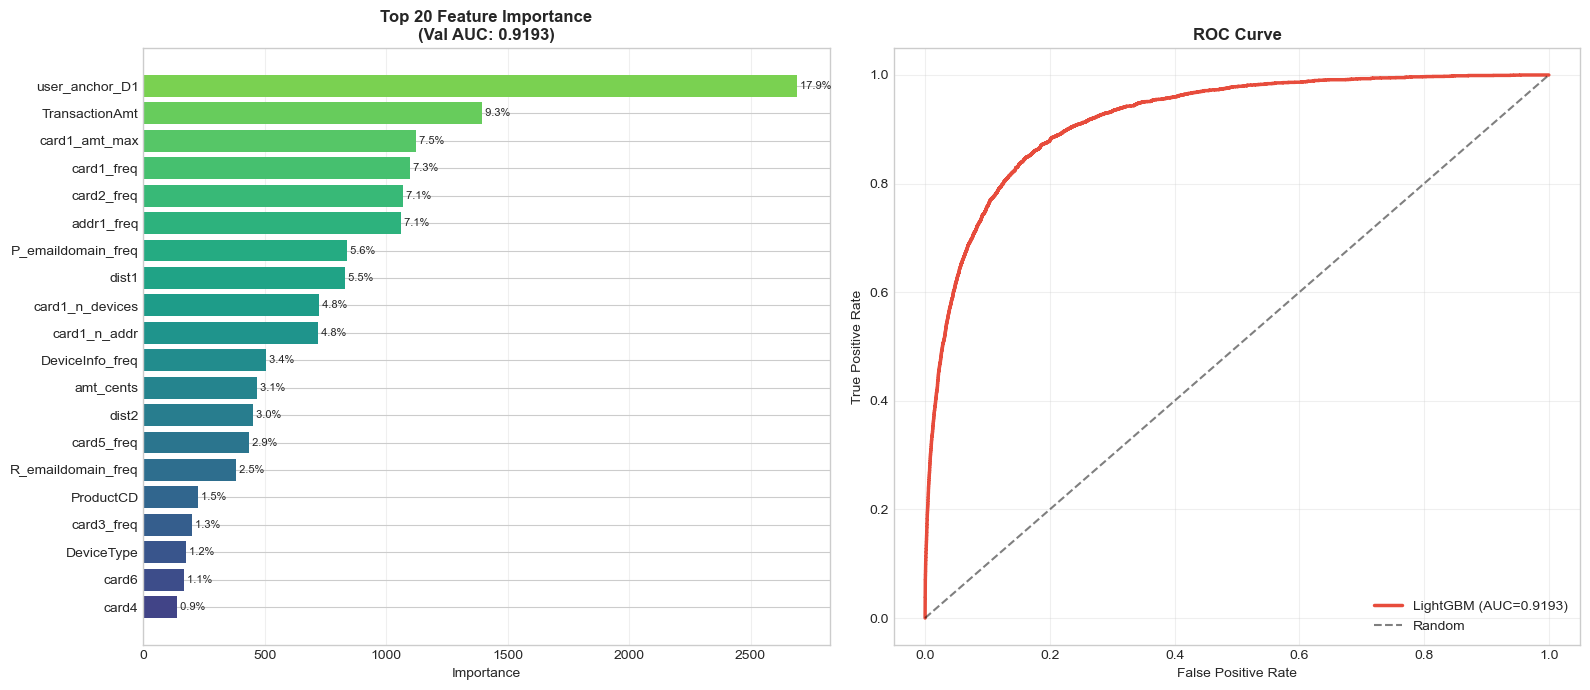

In [18]:
# Visualization: Feature Importance & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Feature Importance (Top 20)
ax1 = axes[0]
top_20 = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(top_20)))
ax1.barh(range(len(top_20)), top_20['importance'], color=colors)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance')
ax1.set_title(f'Top 20 Feature Importance\n(Val AUC: {val_auc:.4f})', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, axis='x')

for i, (_, row) in enumerate(top_20.iterrows()):
    ax1.text(row['importance'], i, f" {row['importance_pct']:.1f}%", va='center', fontsize=8)

# ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'LightGBM (AUC={val_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold', fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 17. Low Importance Feature Analysis

Düşük önemli özellikler model karmaşıklığını artırır ve performansı düşürebilir. Bu analiz, çıkarılabilecek özellikleri belirler.

In [19]:
# Identify low importance features
very_low_importance = feature_importance[feature_importance['importance_pct'] < 0.1]['feature'].tolist()
zero_importance = feature_importance[feature_importance['importance'] == 0]['feature'].tolist()

print("LOW IMPORTANCE FEATURE ANALYSIS\n")
print(f"Very low importance (<0.1%): {len(very_low_importance)}")
print(f"Zero importance            : {len(zero_importance)}")

if very_low_importance:
    print(f"\nVery Low Importance Features:")
    for feat in very_low_importance[:15]:
        imp_pct = feature_importance[feature_importance['feature'] == feat]['importance_pct'].values[0]
        print(f"  • {feat}: {imp_pct:.3f}%")
    if len(very_low_importance) > 15:
        print(f"  ... and {len(very_low_importance)-15} more")

print(f"\n💡 Recommendation: Consider dropping {len(very_low_importance)} low-value features")

LOW IMPORTANCE FEATURE ANALYSIS

Very low importance (<0.1%): 4
Zero importance            : 3

Very Low Importance Features:
  • addr2_freq: 0.087%
  • has_cents_1: 0.000%
  • is_round_amount_1: 0.000%
  • is_psych_amount_1: 0.000%

💡 Recommendation: Consider dropping 4 low-value features


---
##  Özet ve Sonraki Adımlar

### Yapılanlar:
1.  Temporal features oluşturuldu (week_num, month_num)
2.  User identification (UID) Chris Deotte yaklaşımı ile yapıldı
3.  UID behavioral features hesaplandı (ortalama, std, max, min, toplam)
4.  Card1 aggregation features eklendi (train-only, data leakage önlendi)
5.  Psychological amount features oluşturuldu
6.  Missing value handling yapıldı
7.  High correlation features belirlendi ve çıkarıldı
8.  Encoding stratejisi uygulandı
9.  LightGBM modeli eğitildi ve değerlendirildi
10.  Feature importance analizi yapıldı

### Sonraki Adımlar:
- Düşük önemli özelliklerin çıkarılması
- Hyperparameter tuning
- Ensemble modeller denenmesi
- Test verisi üzerinde final prediction